# Modelo supervisionado para previsao de falha - MetroPT-3

Objetivo: usar os horarios de falha informados na documentacao para criar rotulos `sim`/`nao` e treinar um modelo supervisionado capaz de indicar risco antes da falha acontecer.

Estrategia usada:

- `is_failure = 1`: intervalo em que a falha ja esta acontecendo.
- `target_pre_failure = 1`: janela de 24 horas antes do inicio da falha.
- `target_pre_failure = 0`: operacao sem falha conhecida nem janela de alerta.

Para manutencao preditiva, o alvo mais util e `target_pre_failure`, porque ele representa o periodo em que queremos gerar alerta.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (15, 5)

DATA_PATH = Path('metropt+3+dataset/MetroPT3(AirCompressor).csv')
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

LOOKAHEAD_HOURS = 24
DATA_PATH

WindowsPath('metropt+3+dataset/MetroPT3(AirCompressor).csv')

## 1. Leitura dos dados

O dataset tem mais de 15 milhoes de linhas. As colunas dos sensores sao lidas como `float32` para reduzir uso de memoria.

In [2]:
sensor_cols = [
    'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature',
    'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
    'Pressure_switch', 'Oil_level', 'Caudal_impulses'
]

dtype_map = {col: 'float32' for col in sensor_cols}

df = pd.read_csv(
    DATA_PATH,
    usecols=['timestamp'] + sensor_cols,
    parse_dates=['timestamp'],
    dtype=dtype_map
)

df = df.sort_values('timestamp').set_index('timestamp')
print(df.shape)
df.head()

(1516948, 15)


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.599998,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.674999,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.599998,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.424999,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.474998,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [3]:
display(df.describe().T)
print('Inicio:', df.index.min())
print('Fim:', df.index.max())
print('Valores ausentes:', int(df.isna().sum().sum()))

,count,mean,std,min,25%,50%,75%,max
TP2,1516948.0,1.367826,3.250930,-0.032,-0.014000,-0.012000,-0.0100,10.676000
TP3,1516948.0,8.984611,0.639095,0.730,8.492000,8.960000,9.4920,10.302000
H1,1516948.0,7.568155,3.333200,-0.036,8.254000,8.784000,9.3740,10.288000
DV_pressure,1516948.0,0.055956,0.382402,-0.032,-0.022000,-0.020000,-0.0180,9.844000
Reservoirs,1516948.0,8.985233,0.638307,0.712,8.494000,8.960000,9.4920,10.300000
Oil_temperature,1516948.0,62.644184,6.516261,15.400,57.775002,62.700001,67.2500,89.050003
Motor_current,1516948.0,2.050171,2.302053,0.020,0.040000,0.045000,3.8075,9.295000
COMP,1516948.0,0.836957,0.369405,0.000,1.000000,1.000000,1.0000,1.000000
DV_eletric,1516948.0,0.160611,0.367172,0.000,0.000000,0.000000,0.0000,1.000000
Towers,1516948.0,0.919848,0.271528,0.000,1.000000,1.000000,1.0000,1.000000


Inicio: 2020-02-01 00:00:00
Fim: 2020-09-01 03:59:50
Valores ausentes: 0


## 2. Intervalos de falha conhecidos

Esses intervalos vem da documentacao do dataset. Eles serao usados para criar os rotulos supervisionados.

In [4]:
failure_windows = [
    ('2020-04-18 00:00:00', '2020-04-18 23:59:00', 'Air leak'),
    ('2020-05-29 23:30:00', '2020-05-30 06:00:00', 'Air leak'),
    ('2020-06-05 10:00:00', '2020-06-07 14:30:00', 'Air leak'),
    ('2020-07-15 14:30:00', '2020-07-15 19:00:00', 'Air leak'),
]

failures = pd.DataFrame(failure_windows, columns=['start', 'end', 'failure_type'])
failures['start'] = pd.to_datetime(failures['start'])
failures['end'] = pd.to_datetime(failures['end'])
failures

,start,end,failure_type
0,2020-04-18 00:00:00,2020-04-18 23:59:00,Air leak
1,2020-05-29 23:30:00,2020-05-30 06:00:00,Air leak
2,2020-06-05 10:00:00,2020-06-07 14:30:00,Air leak
3,2020-07-15 14:30:00,2020-07-15 19:00:00,Air leak


## 3. Agregacao por minuto e criacao de atributos

Os dados originais estao em frequencia proxima de 1 Hz. Para reduzir ruido e custo computacional, cada minuto vira uma linha com estatisticas dos sensores.

In [5]:
analog_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

analog_agg = df[analog_cols].resample('1min').agg(['mean', 'std', 'min', 'max'])
analog_agg.columns = [f'{col}_{stat}' for col, stat in analog_agg.columns]

digital_agg = df[digital_cols].resample('1min').mean()
digital_agg.columns = [f'{col}_rate' for col in digital_agg.columns]

features = pd.concat([analog_agg, digital_agg], axis=1)
features = features.ffill().bfill()

base_level_cols = [f'{col}_mean' for col in analog_cols]
delta_features = features[base_level_cols].diff().add_suffix('_delta')
rolling_features = features[base_level_cols].rolling('15min', min_periods=3).std().add_suffix('_roll15_std')

features = pd.concat([features, delta_features, rolling_features], axis=1).replace([np.inf, -np.inf], np.nan)
features = features.ffill().bfill()

print(features.shape)
features.head()

(306960, 50)


,TP2_mean,TP2_std,TP2_min,TP2_max,TP3_mean,TP3_std,TP3_min,TP3_max,H1_mean,H1_std,...,Reservoirs_mean_delta,Oil_temperature_mean_delta,Motor_current_mean_delta,TP2_mean_roll15_std,TP3_mean_roll15_std,H1_mean_roll15_std,DV_pressure_mean_roll15_std,Reservoirs_mean_roll15_std,Oil_temperature_mean_roll15_std,Motor_current_mean_roll15_std
timestamp,,,,,,,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012286,0.000756,-0.014,-0.012,9.327429,0.022382,9.296,9.358,9.311143,0.021935,...,-0.068334,-0.100594,-0.000357,0.000357,0.064569,0.064598,0.000500,0.064538,0.098223,0.000206
2020-02-01 00:01:00,-0.013000,0.001095,-0.014,-0.012,9.260000,0.019718,9.232,9.286,9.243333,0.019705,...,-0.068334,-0.100594,-0.000357,0.000357,0.064569,0.064598,0.000500,0.064538,0.098223,0.000206
2020-02-01 00:02:00,-0.012667,0.001033,-0.014,-0.012,9.198334,0.019572,9.172,9.224,9.182000,0.018847,...,-0.060666,-0.095833,0.000000,0.000357,0.064569,0.064598,0.000500,0.064538,0.098223,0.000206
2020-02-01 00:03:00,-0.012333,0.000816,-0.014,-0.012,9.136666,0.019253,9.110,9.162,9.120667,0.019253,...,-0.062334,-0.125000,0.000000,0.000332,0.081863,0.081715,0.000418,0.081962,0.137111,0.000179
2020-02-01 00:04:00,-0.013000,0.001095,-0.014,-0.012,9.075667,0.019159,9.050,9.100,9.060000,0.018633,...,-0.060999,-0.070835,0.000000,0.000346,0.099134,0.098837,0.000373,0.099266,0.159358,0.000160


## 4. Criacao dos rotulos supervisionados

Aqui sao criadas tres marcacoes:

- `is_failure`: falha acontecendo.
- `is_pre_failure`: 24 horas antes da falha.
- `target_pre_failure`: alvo do modelo, igual a `is_pre_failure`.

As linhas durante a falha sao removidas do treino/teste principal, porque o objetivo e prever antes.

In [6]:
labeled = features.copy()
labeled['is_failure'] = 0
labeled['is_pre_failure'] = 0

for row in failures.itertuples(index=False):
    failure_mask = (labeled.index >= row.start) & (labeled.index <= row.end)
    pre_failure_mask = (
        (labeled.index >= row.start - pd.Timedelta(hours=LOOKAHEAD_HOURS))
        & (labeled.index < row.start)
    )

    labeled.loc[failure_mask, 'is_failure'] = 1
    labeled.loc[pre_failure_mask, 'is_pre_failure'] = 1

labeled['target_pre_failure'] = labeled['is_pre_failure']

label_summary = labeled[['is_pre_failure', 'is_failure', 'target_pre_failure']].sum().to_frame('linhas')
label_summary['horas_aprox'] = label_summary['linhas'] / 60
label_summary

,linhas,horas_aprox
is_pre_failure,5760,96.00
is_failure,5253,87.55
target_pre_failure,5760,96.00


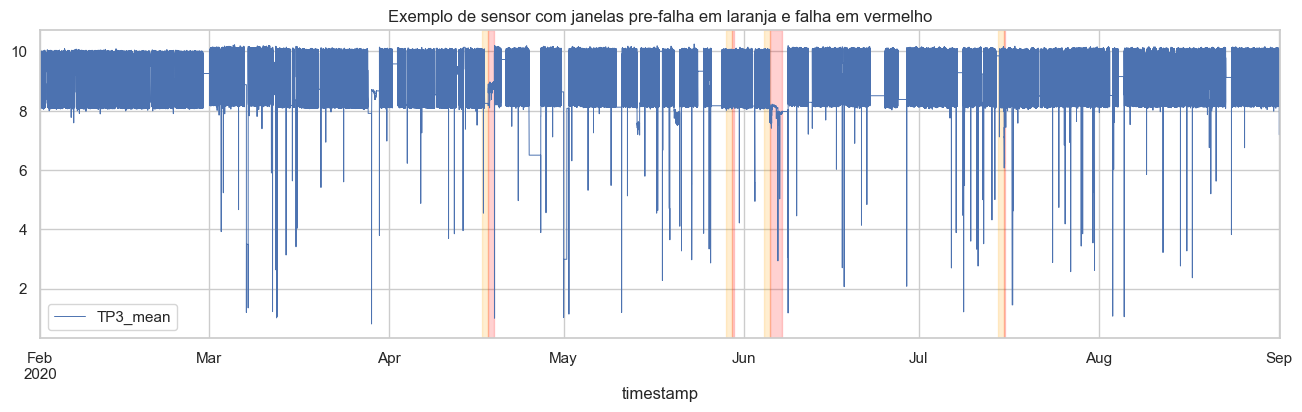

In [7]:
fig, ax = plt.subplots(figsize=(16, 4))
labeled['TP3_mean'].plot(ax=ax, linewidth=0.7, label='TP3_mean')

for row in failures.itertuples(index=False):
    ax.axvspan(row.start - pd.Timedelta(hours=LOOKAHEAD_HOURS), row.start, color='orange', alpha=0.18)
    ax.axvspan(row.start, row.end, color='red', alpha=0.18)

ax.set_title('Exemplo de sensor com janelas pre-falha em laranja e falha em vermelho')
ax.legend()
plt.show()

## 5. Divisao temporal treino/teste

Para evitar vazamento de informacao do futuro, o teste fica no periodo do ultimo evento. O treino usa os eventos anteriores. Isso e mais realista do que embaralhar linhas aleatoriamente em uma serie temporal.

In [8]:
label_cols = ['is_failure', 'is_pre_failure', 'target_pre_failure']
feature_cols = [col for col in labeled.columns if col not in label_cols]

last_event_start = failures['start'].max()
test_start = last_event_start - pd.Timedelta(hours=LOOKAHEAD_HOURS)

model_data = labeled[labeled['is_failure'] == 0].copy()

train_mask = model_data.index < test_start
test_mask = model_data.index >= test_start

X_train = model_data.loc[train_mask, feature_cols]
y_train = model_data.loc[train_mask, 'target_pre_failure']
X_test = model_data.loc[test_mask, feature_cols]
y_test = model_data.loc[test_mask, 'target_pre_failure']

print('Inicio do teste:', test_start)
print('Treino:', X_train.shape, 'positivos:', int(y_train.sum()), 'negativos:', int((y_train == 0).sum()))
print('Teste:', X_test.shape, 'positivos:', int(y_test.sum()), 'negativos:', int((y_test == 0).sum()))

Inicio do teste: 2020-07-14 14:30:00
Treino: (232048, 50) positivos: 4320 negativos: 227728
Teste: (69659, 50) positivos: 1440 negativos: 68219


## 6. Treino do modelo supervisionado

O `RandomForestClassifier` lida bem com relacoes nao lineares e permite ver a importancia das variaveis. `class_weight='balanced_subsample'` ajuda no desbalanceamento, pois existem muito mais periodos normais do que pre-falha.

In [9]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


## 7. Avaliacao do modelo

A saida principal e a probabilidade de estar em janela pre-falha. O threshold padrao e `0.50`, mas em manutencao preditiva normalmente vale testar thresholds menores para aumentar a sensibilidade.

              precision    recall  f1-score   support

      normal       0.96      0.54      0.69     68219
   pre_falha       0.00      0.02      0.00      1440

    accuracy                           0.53     69659
   macro avg       0.48      0.28      0.35     69659
weighted avg       0.94      0.53      0.68     69659

Average precision: 0.0135


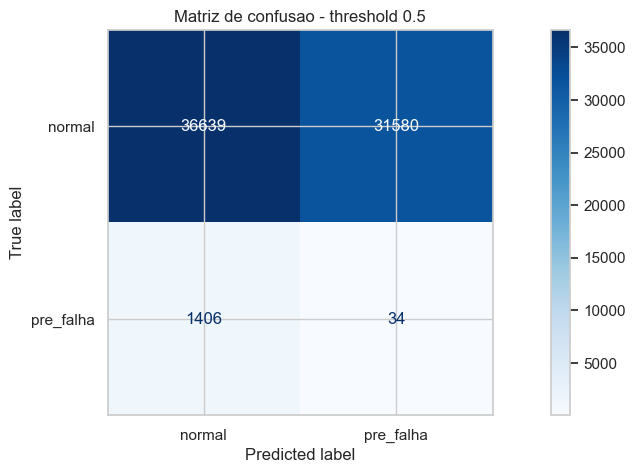

In [10]:
y_proba = clf.predict_proba(X_test)[:, 1]
threshold = 0.50
y_pred = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred, target_names=['normal', 'pre_falha'], zero_division=0))
print('Average precision:', round(average_precision_score(y_test, y_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['normal', 'pre_falha'], cmap='Blues')
plt.title(f'Matriz de confusao - threshold {threshold}')
plt.show()

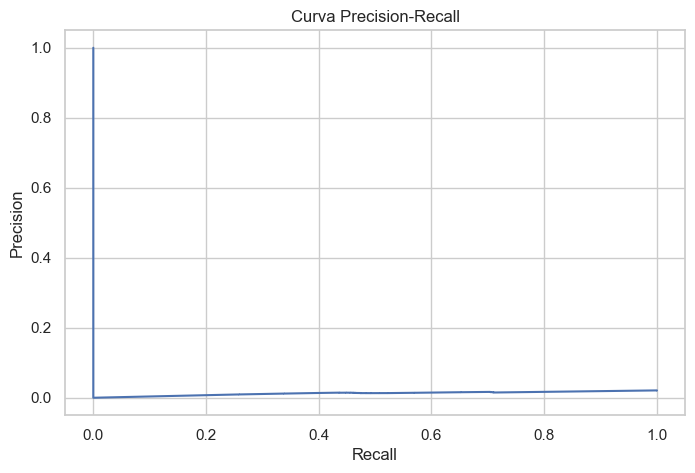

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.show()

## 8. Probabilidade de risco ao longo do tempo

O grafico abaixo mostra se a probabilidade sobe nas 24 horas antes da ultima falha, que ficou no conjunto de teste.

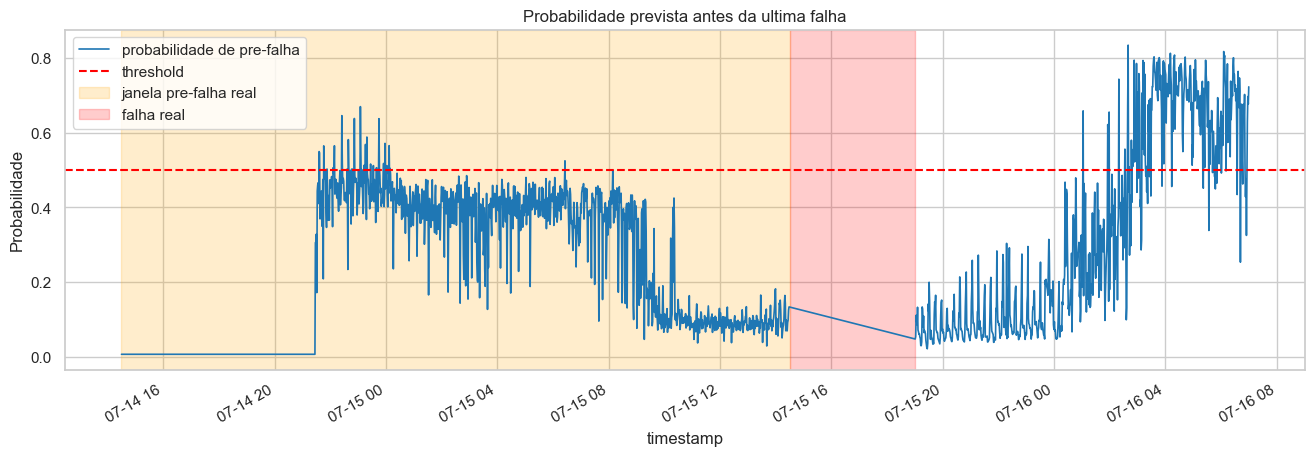

In [12]:
test_result = model_data.loc[test_mask, ['is_pre_failure']].copy()
test_result['risk_probability'] = y_proba
test_result['predicted_pre_failure'] = y_pred

last_event = failures.loc[failures['start'].idxmax()]
view_start = last_event['start'] - pd.Timedelta(hours=48)
view_end = last_event['end'] + pd.Timedelta(hours=12)
plot_data = test_result.loc[view_start:view_end]

fig, ax = plt.subplots(figsize=(16, 5))
plot_data['risk_probability'].plot(ax=ax, linewidth=1.2, color='#1f77b4', label='probabilidade de pre-falha')
ax.axhline(threshold, color='red', linestyle='--', label='threshold')
ax.axvspan(last_event['start'] - pd.Timedelta(hours=LOOKAHEAD_HOURS), last_event['start'], color='orange', alpha=0.2, label='janela pre-falha real')
ax.axvspan(last_event['start'], last_event['end'], color='red', alpha=0.2, label='falha real')
ax.set_title('Probabilidade prevista antes da ultima falha')
ax.set_ylabel('Probabilidade')
ax.legend()
plt.show()

## 9. Importancia das variaveis

A importancia ajuda a interpretar quais sensores e estatisticas mais influenciaram o modelo.

,feature,importance
22,Oil_temperature_min,0.066920
20,Oil_temperature_mean,0.066881
23,Oil_temperature_max,0.065056
12,DV_pressure_mean,0.054878
17,Reservoirs_std,0.045604
5,TP3_std,0.045163
14,DV_pressure_min,0.043662
48,Oil_temperature_mean_roll15_std,0.040661
0,TP2_mean,0.035881
3,TP2_max,0.033764


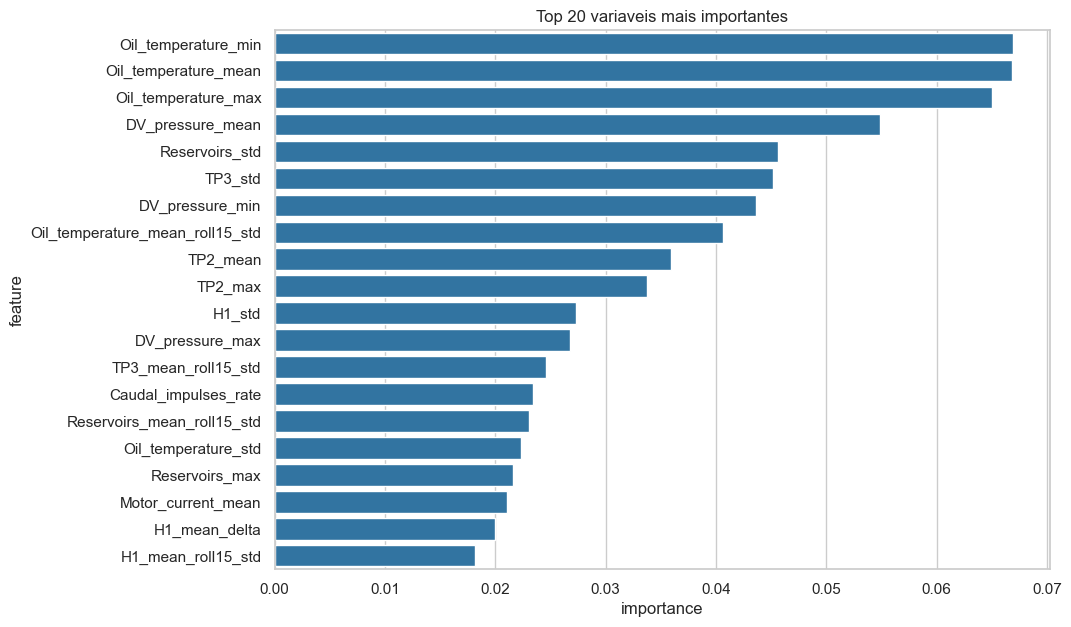

In [13]:
rf = clf.named_steps['model']
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

display(importance.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance.head(20), x='importance', y='feature', color='#1f77b4')
plt.title('Top 20 variaveis mais importantes')
plt.show()

## 10. Exportacao

Sao salvos o modelo treinado, as probabilidades do teste e a base agregada com rotulos.

In [14]:
labeled.to_csv(ARTIFACT_DIR / 'metro_supervised_labeled_data.csv')
test_result.to_csv(ARTIFACT_DIR / 'metro_supervised_test_predictions.csv')
joblib.dump({
    'model': clf,
    'threshold': threshold,
    'feature_cols': feature_cols,
    'lookahead_hours': LOOKAHEAD_HOURS,
    'failures': failures
}, ARTIFACT_DIR / 'metro_supervised_random_forest.joblib')

print('Arquivos salvos em:', ARTIFACT_DIR.resolve())

Arquivos salvos em: C:\Users\walis\OneDrive\Documentos\atividades_facul\Trabalho_SI_T\artifacts


## Interpretacao final

- Este notebook agora e supervisionado, porque usa rotulos criados a partir dos horarios de falha.
- Se `risk_probability` sobe antes da faixa vermelha, o modelo esta capturando sinais antecipados.
- Se o recall estiver baixo, reduza o `threshold`, por exemplo para `0.30` ou `0.20`.
- Se houver muitos falsos positivos, aumente o `threshold`.
- Como existem apenas 4 falhas reportadas, a avaliacao ainda e limitada. O resultado deve ser tratado como um prototipo supervisionado, nao como um modelo pronto para producao.

## 11. Abordagem Não Supervisionada: Agrupamento com K-Means

Como observado na modelagem supervisionada, o desbalanceamento extremo de classes e o desvio temporal das variáveis térmicas (efeito sazonal no verão) dificultam a classificação supervisionada tradicional.

Para complementar o trabalho, implementamos uma **abordagem não supervisionada utilizando o K-Means** para agrupar as leituras dos sensores em estados físicos de operação e avaliar se esses estados se comportam de maneira anômala nos períodos que antecedem as falhas.

In [ ]:
from sklearn.cluster import KMeans

# 1. Selecionar as variáveis base dos sensores (sem as derivadas de médias móveis ou deltas)
base_cols = [
    'TP2_mean', 'TP3_mean', 'H1_mean', 'DV_pressure_mean', 'Reservoirs_mean', 
    'Oil_temperature_mean', 'Motor_current_mean', 
    'COMP_rate', 'DV_eletric_rate', 'Towers_rate', 'MPG_rate', 'LPS_rate', 
    'Pressure_switch_rate', 'Oil_level_rate', 'Caudal_impulses_rate'
]

# 2. Normalizar as variáveis
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(labeled[base_cols])

# 3. Treinar o modelo K-Means com 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labeled['cluster'] = kmeans.fit_predict(X_scaled)

print("Treinamento do K-Means concluído!")

In [ ]:
# Média das principais variáveis físicas por cluster para perfilamento físico
profile = labeled.groupby('cluster')[
    ['Motor_current_mean', 'TP2_mean', 'TP3_mean', 'Reservoirs_mean', 'Oil_temperature_mean', 'COMP_rate', 'is_pre_failure', 'is_failure']
].mean()

print("=== Média das Variáveis por Cluster ===")
display(profile)

### Interpretação Física dos Clusters Obtidos:

* **Cluster 0**: Compressor em transição/vazio (corrente do motor intermediária, pressão de saída TP2 baixa, COMP alto).
* **Cluster 1**: Estado atípico/manutenção (pressão e temperatura extremamente baixas, COMP baixo).
* **Cluster 2**: **Compressor sob carga (Ativo)** (motor consumindo corrente elevada de ~5.5A, pressão TP2 alta de ~8.3 bar). Este é o estado de maior estresse do compressor.
* **Cluster 3**: **Compressor desligado/idle** (corrente próxima de 0A, pressão TP2 baixa de ~0.04 bar, COMP ativado).

In [ ]:
# Visualização da transição de estados para a Falha 1 (18/04/2020)
sub_df = labeled.loc['2020-04-12':'2020-04-19'].copy()
sub_df['date'] = sub_df.index.date
pivot = sub_df.groupby(['date', 'cluster']).size().unstack(fill_value=0)

# Converter em porcentagem do dia
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 5))
plt.title('Distribuição diária de Clusters - Falha 1 (18/04/2020)')
plt.xlabel('Data')
plt.ylabel('Porcentagem do Dia (%)')
plt.legend(['Cluster 0 (Transição)', 'Cluster 1 (Atípico)', 'Cluster 2 (Sob Carga)', 'Cluster 3 (Desligado)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Visualização da transição de estados para a Falha 4 (Test Set: 15/07/2020)
sub_df_4 = labeled.loc['2020-07-10':'2020-07-16'].copy()
sub_df_4['date'] = sub_df_4.index.date
pivot_4 = sub_df_4.groupby(['date', 'cluster']).size().unstack(fill_value=0)

# Converter em porcentagem do dia
pivot_pct_4 = pivot_4.div(pivot_4.sum(axis=1), axis=0) * 100

pivot_pct_4.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 5))
plt.title('Distribuição diária de Clusters - Falha 4 (15/07/2020)')
plt.xlabel('Data')
plt.ylabel('Porcentagem do Dia (%)')
plt.legend(['Cluster 0 (Transição)', 'Cluster 1 (Atípico)', 'Cluster 2 (Sob Carga)', 'Cluster 3 (Desligado)'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusão do Agrupamento não Supervisionado

A visualização gráfica por agrupamento revela a falha mecânica de forma nítida:

1. **Comportamento Normal**: Sob condições saudáveis de operação (ex: dias 12 a 16 de abril), o compressor passa a maior parte do tempo **desligado/idle (Cluster 3)** ou em **transição (Cluster 0)**, operando **sob carga (Cluster 2)** apenas cerca de 10% a 15% do dia (cerca de 2 horas).
2. **Assinatura da Falha**: Nos dias das falhas reais (18/04 e 15/07), o compressor passa **quase 100% do dia operando sob carga (Cluster 2)**. 
3. **Detecção Precoce**: Como visto no gráfico da Falha 4, há um aumento perceptível do uso sob carga (Cluster 2) nos dias imediatamente anteriores à falha.

Essa análise mostra que o agrupamento com K-Means consegue segmentar perfeitamente o perfil de estresse operacional do equipamento. Em termos de manutenção preditiva, monitorar a proporção diária de tempo em que o compressor fica ativo sob carga é um indicador muito simples e robusto para gerar alarmes preventivos.